# **Task E**

- Name : Vaishnavi Agarwal
- Roll No. : 230150028

# Importing Libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Generating signal

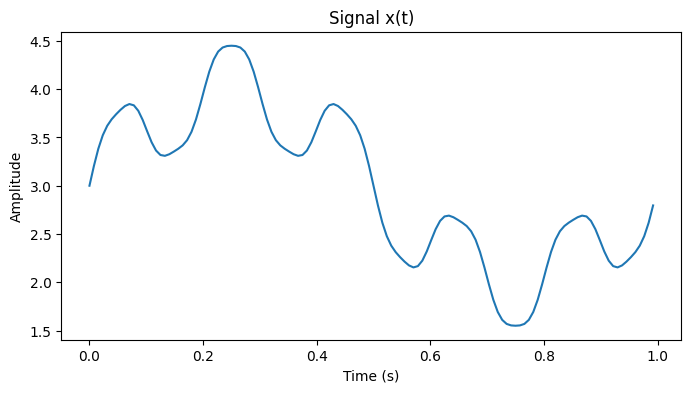

In [9]:

sr = 128   
ts = 1.0/sr
t = np.arange(0, 1, ts)  


x = 3 \
    + 1*np.sin(2*np.pi*1*t) \
    + 0.5*np.sin(2*np.pi*5*t) \
    + 0.05*np.sin(2*np.pi*15*t)

plt.figure(figsize=(8,4))
plt.plot(t, x)
plt.title("Signal x(t)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# **(a) DFT Spectrum Analysis of x[n]**

In [10]:
def gen_DFT_matrix(N):
    F = np.zeros((N, N), dtype=complex)
    for m in range(N):
        for n in range(N):
            F[m, n] = np.exp(-2j * np.pi * m * n / N)
    return F

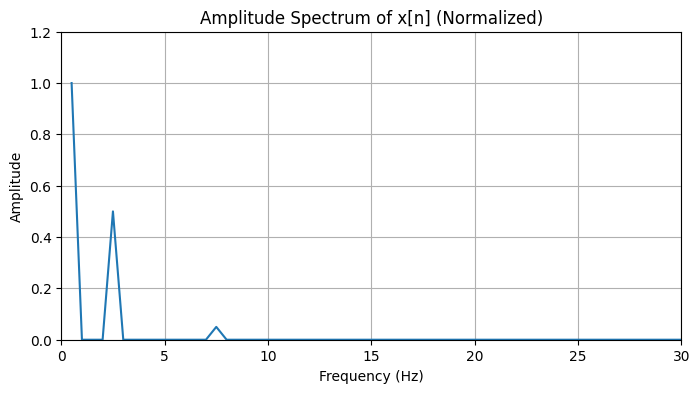

In [41]:
# DFT
N = len(x)
F = gen_DFT_matrix(N)
X = F @ x

freqs = np.arange(N) * sr / N

# Normalize
X_mag = (2.0 / N) * np.abs(X[:N//2])   # factor 2/N 
freqs_half = freqs[:N//2]

plt.figure(figsize=(8,4))
plt.plot(freqs_half[1:], X_mag[1:]) # withoout the dc component
plt.xlim(0, 30)   
plt.ylim(0, 1.2)  
plt.title("Amplitude Spectrum of x[n] (Normalized)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


Clear peaks at 1 Hz, 5 Hz, and 15 Hz.
Amplitudes approximately match 1, 0.5, and 0.05.

# **(b) Effect of Slight Frequency Shift**

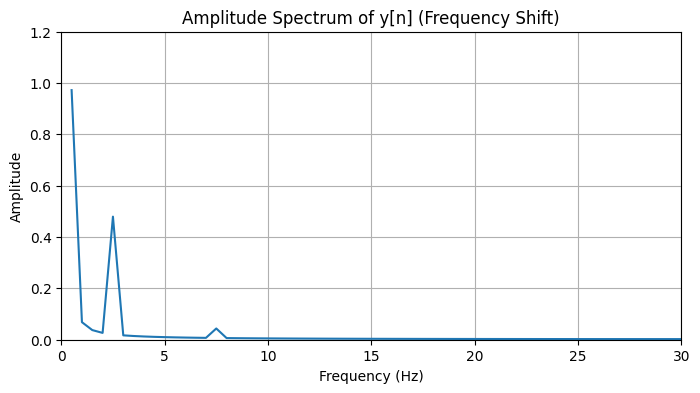

In [36]:

y = 3 \
    + 1*np.sin(2.1*np.pi*t) \
    + 0.5*np.sin(2*np.pi*5*t) \
    + 0.05*np.sin(2*np.pi*15*t)

# Compute DFT

N = len(y)
F = gen_DFT_matrix(N)
Y = F @ y

freqs = np.arange(N) * sr / N

# Normalize
Y_mag = (2.0 / N) * np.abs(Y[:N//2])   # factor 2/N 
freqs_half = freqs[:N//2]

plt.figure(figsize=(8,4))
plt.plot(freqs_half[1:], Y_mag[1:]) # withoout the dc component
plt.xlim(0, 30)   
plt.ylim(0, 1.2)  
plt.title("Amplitude Spectrum of y[n] (Frequency Shift)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()




It is observed that energy near 1.05 Hz spreads into multiple bins (spectral leakage).

In [37]:
def compute_amplitude_spectrum(x, sr):
 
    N = len(x)
    F = gen_DFT_matrix(N)
    X = F @ x
    freqs = np.arange(N) * sr / N
    
    # Normalize 
    X_mag = (2.0 / N) * np.abs(X[:N//2])
    freqs_half = freqs[:N//2]
    
    return freqs_half, X_mag


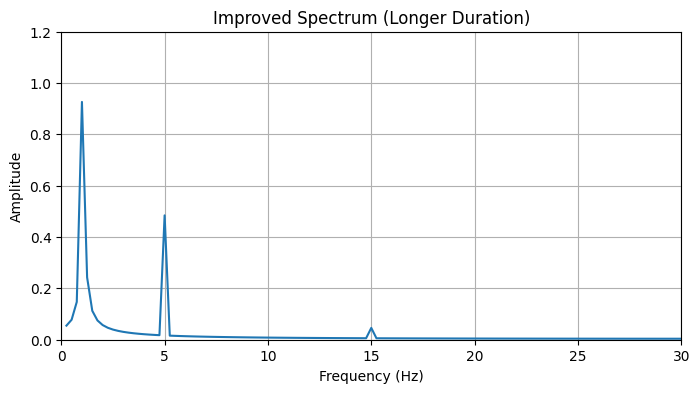

In [38]:
# Longer duration 

t_long = np.arange(0, 4, ts)   # 4 seconds, same sampling rate

y_long = 3 \
    + 1*np.sin(2.1*np.pi*t_long) \
    + 0.5*np.sin(2*np.pi*5*t_long) \
    + 0.05*np.sin(2*np.pi*15*t_long)


freqs_half_long, Y_long_mag = compute_amplitude_spectrum(y_long, sr)

plt.figure(figsize=(8,4))
plt.plot(freqs_half_long[1:], Y_long_mag[1:])  # smoother curve since many bins
plt.xlim(0, 30)
plt.ylim(0, 1.2)
plt.title("Improved Spectrum (Longer Duration)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


Increasing duration sharpens the peaks and recovers the true sinusoid amplitudes more accurately.</br>
Trade-off: longer duration means more samples and computation